# Reload Data Mesh Domains & Capture Snapshots

This notebook reloads clean data from Silver-data into Data_Mesh_Domains, simulates multiple reloads, and captures domain health snapshots for anomaly model training.

## 1. Import Required Libraries

In [1]:
import os
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Load and Inspect Silver-data

In [2]:
silver_path = '../Data/Silver-data/'
domain_path = '../Data_Mesh_Domains/'
silver_files = [f for f in os.listdir(silver_path) if f.endswith('_clean.csv')]
print('Silver-data files:', silver_files)
# Inspect one file
sample_df = pd.read_csv(os.path.join(silver_path, silver_files[0]))
sample_df.head()

Silver-data files: ['users_preferences_clean.csv', 'transactions_clean.csv', 'trends_clean.csv', 'interactions_clean.csv', 'users_clean.csv', 'shops_clean.csv', 'products_clean.csv']


,preference_id,user_id,preferred_categories,preferred_colors,preferred_fabrics,preferred_brands,preferred_styles,skin_tone,body_type,price_sensitivity,updated_ts
0,1,1,"UTILITY PANTS, CHINOS, OVERSIZE TEE","Brown, Off-white, Teal","Modal, Cotton",Brand_3,"Casual, Athleisure, Formal",Medium Skin,Tall Friendly,Medium,2025-11-19 14:56:19.269218
1,2,2,"JOGGERS & PANTS, BLAZERS, SHORTS","Polka Dot, Teal, Tan","Linen, Denim",Brand_6,"Athleisure, Formal, Beach Wear",Medium Skin,Curvy Friendly,Medium,2025-11-19 14:56:19.269398
2,3,3,"COATS, JOGGERS & PANTS, SWEATSHIRTS","Brown, Tan, Yellow","Denim, Modal",Brand_19,"Hipster, Beach Wear, Eco-friendly",Dark Skin,Curvy Friendly,Medium,2025-11-19 14:56:19.269539
3,4,4,"BEACH WEAR, COATS, UTILITY PANTS","Red, Striped, Peach","Linen, Fleece",Brand_8,"Hipster, Luxury, Y2K",Fair Skin,Skinny Friendly,Medium,2025-11-19 14:56:19.269663
4,5,5,"SHORTS, OVERSIZE TEE, UTILITY PANTS","Tie-dye, Orange, Charcoal","Bamboo, Tencel",Brand_1,"Luxury, Casual, Preppy",Dark Skin,Curvy Friendly,High,2025-11-19 14:56:19.269789


## 3. Define Reload Function

In [3]:
def reload_domains_from_silver(silver_path, domain_path):
    """Copy each clean CSV from Silver-data to the corresponding Data_Mesh_Domains/<domain> folder."""
    mapping = {
        'users_clean.csv': 'users_domain/users_domain.csv',
        'products_clean.csv': 'product_domain/product_domain.csv',
        'shops_clean.csv': 'shop_domain/shop_domain.csv',
        'transactions_clean.csv': 'sales_domain/sales_domain.csv',
        'trends_clean.csv': 'engagement_domain/engagement_domain.csv',
        'users_preferences_clean.csv': 'user_preferences_domain/user_preferences_domain.csv',
        'interactions_clean.csv': 'Interaction_domain/interaction_domain.csv',
    }
    for src, dst in mapping.items():
        src_file = os.path.join(silver_path, src)
        dst_file = os.path.join(domain_path, dst)
        if os.path.exists(src_file):
            shutil.copy(src_file, dst_file)
            print(f'Copied {src_file} to {dst_file}')
        else:
            print(f'Missing: {src_file}')

## 4. Simulate Data Reloads

In [4]:
reload_count = 5
for i in range(reload_count):
    print(f'--- Reload iteration {i+1} ---')
    reload_domains_from_silver(silver_path, domain_path)
    # Optionally, modify Silver-data slightly here for more variation
    # Wait or simulate time passing if needed

--- Reload iteration 1 ---
Copied ../Data/Silver-data/users_clean.csv to ../Data_Mesh_Domains/users_domain/users_domain.csv
Copied ../Data/Silver-data/products_clean.csv to ../Data_Mesh_Domains/product_domain/product_domain.csv
Copied ../Data/Silver-data/shops_clean.csv to ../Data_Mesh_Domains/shop_domain/shop_domain.csv
Copied ../Data/Silver-data/transactions_clean.csv to ../Data_Mesh_Domains/sales_domain/sales_domain.csv
Copied ../Data/Silver-data/trends_clean.csv to ../Data_Mesh_Domains/engagement_domain/engagement_domain.csv
Copied ../Data/Silver-data/users_preferences_clean.csv to ../Data_Mesh_Domains/user_preferences_domain/user_preferences_domain.csv
Copied ../Data/Silver-data/interactions_clean.csv to ../Data_Mesh_Domains/Interaction_domain/interaction_domain.csv
--- Reload iteration 2 ---
Copied ../Data/Silver-data/users_clean.csv to ../Data_Mesh_Domains/users_domain/users_domain.csv
Copied ../Data/Silver-data/products_clean.csv to ../Data_Mesh_Domains/product_domain/product_d

## 5. Capture Snapshots

In [5]:
snapshots = []
from datetime import datetime

def capture_snapshot():
    # Example: count rows in each domain
    snapshot = {}
    for domain in os.listdir(domain_path):
        domain_dir = os.path.join(domain_path, domain)
        for file in os.listdir(domain_dir):
            if file.endswith('.csv'):
                df = pd.read_csv(os.path.join(domain_dir, file))
                snapshot[f'{domain}'] = len(df)
    snapshot['timestamp'] = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    return snapshot

for i in range(reload_count):
    snap = capture_snapshot()
    snapshots.append(snap)
    print(f'Snapshot {i+1}:', snap)

Snapshot 1: {'users_domain': 508, 'sales_domain': 8008, 'user_preferences_domain': 471, 'engagement_domain': 222, 'Interaction_domain': 2856, 'shop_domain': 24, 'metadata': 7, 'product_domain': 2483, 'timestamp': '2026-01-06 01:45:16'}
Snapshot 2: {'users_domain': 508, 'sales_domain': 8008, 'user_preferences_domain': 471, 'engagement_domain': 222, 'Interaction_domain': 2856, 'shop_domain': 24, 'metadata': 7, 'product_domain': 2483, 'timestamp': '2026-01-06 01:45:16'}
Snapshot 3: {'users_domain': 508, 'sales_domain': 8008, 'user_preferences_domain': 471, 'engagement_domain': 222, 'Interaction_domain': 2856, 'shop_domain': 24, 'metadata': 7, 'product_domain': 2483, 'timestamp': '2026-01-06 01:45:16'}
Snapshot 4: {'users_domain': 508, 'sales_domain': 8008, 'user_preferences_domain': 471, 'engagement_domain': 222, 'Interaction_domain': 2856, 'shop_domain': 24, 'metadata': 7, 'product_domain': 2483, 'timestamp': '2026-01-06 01:45:16'}
Snapshot 5: {'users_domain': 508, 'sales_domain': 8008, 

## 6. Visualize Snapshots

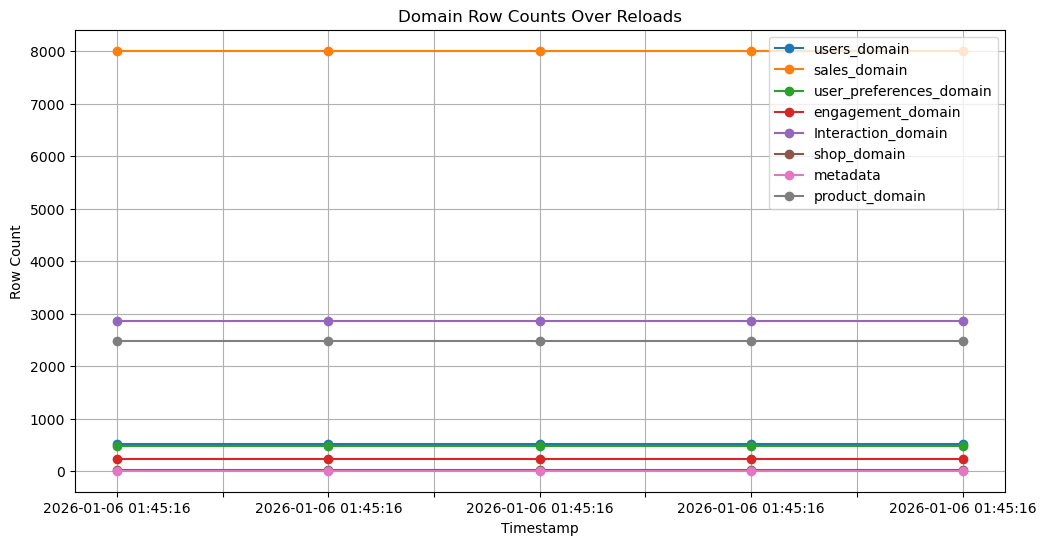

In [6]:
# Convert snapshots to DataFrame
snap_df = pd.DataFrame(snapshots)
snap_df.set_index('timestamp', inplace=True)
snap_df.plot(kind='line', marker='o', figsize=(12,6))
plt.title('Domain Row Counts Over Reloads')
plt.ylabel('Row Count')
plt.xlabel('Timestamp')
plt.grid(True)
plt.show()